# 00 · 수식을 NumPy로 옮기기

**이번 질문:** $z_k=\sum_d x_d W_{dk}+b_k$라는 식을 보고, 배열의 모양과 코드를 직접 정할 수 있을까요?

지금은 이 식이 낯설어도 됩니다. **숫자 두 개 → 샘플 여러 개 → 출력 여러 개**로 한 단계씩 넓히면서
마지막에 이 식 전체를 읽을 수 있게 됩니다. 각 단계에는 완성된 작은 예제와 검산이 있고, 끝에는 직접 바꿔 보는 문제가 있습니다.

- 준비물: Python의 변수·함수·반복문을 읽을 수 있으면 시작할 수 있습니다. 배열 문법은 나오는 자리에서 설명합니다.
- 도착점: 내적, 행렬곱, 브로드캐스팅, 축 합, reshape와 transpose를 구분하고 수식을 코드로 옮깁니다.
- 다음 연결: 여기서 만든 선형 계산을 01번에서 **학습되는 모델**로 만듭니다.

### 읽는 법

셀마다 앞에 표시가 있습니다. 표시를 보고 힘을 어디에 쓸지 정하세요.

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 계산 하나는 "입력 × 가중치를 모두 더하고 편향을 더한다"이고, 코드로는 `x @ w + b`입니다.
2. 배열의 `shape`를 보면 행이 샘플, 열이 특성이라는 뜻까지 같이 읽습니다. `(N, D) @ (D, K) → (N, K)`.
3. 어느 축을 더하고 어느 축을 남기는지를 먼저 정한 뒤 코드를 씁니다.

공부할 때는 먼저 출력값을 예상한 뒤 셀을 실행해 보세요.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/array_plots.py) · [개념 그림 부품](../../src/utils/concept_plots.py) · [구조 도식 부품](../../src/utils/schematic_plots.py)

셀 실행과 풀이 셀 추가가 처음이라면 [README의 Jupyter 안내](../../README.md)를 먼저 따라 해 보세요.

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path

project_root = next(                                   # 현재 폴더부터 위로 올라가며
    p for p in (Path.cwd(), *Path.cwd().parents)       # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
    if (p / "src" / "utils" / "plotting.py").is_file()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy와 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
import numpy as np
from src.utils import setup_plots
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· 준비 완료")

# 3) 이 노트북의 그림 함수(src/utils/array_plots.py), 데이터 로더, 연습 검사 도우미
from src.utils.array_plots import (
    plot_weighted_sum, plot_product, plot_layout, plot_affine_plane,
    plot_dot_as_overlap, plot_batch_rows, plot_templates, plot_axis_sums, plot_reshape_vs_transpose,
    plot_neuron_diagram, plot_layer_diagram, plot_broadcast_ways,
)
from src.data.mnist import load_mnist, load_examples
from src.utils import run_check

NumPy 2.3.5 · 준비 완료


### 📎 이 노트북의 그림 예시: 손글씨 숫자

> **용어**
>
> - **MNIST**: 사람이 손으로 쓴 숫자 0–9를 찍은 이미지 7만 장 모음입니다. 이미지마다 "이건 7"이라는 정답 숫자가 붙어 있습니다. 작고 단순해서 딥러닝을 처음 배울 때 예제로 가장 많이 씁니다.
> - **화소(pixel)**: 이미지를 이루는 작은 네모 칸 하나. 여기서는 칸마다 0(흰색)에서 1(검정) 사이의 숫자 하나가 들어 있습니다.

이 노트북의 수식은 작은 숫자로 손계산해 익힌 뒤, 같은 계산을 MNIST 이미지에서 다시 봅니다.
이미지 한 장은 28×28 = 784개의 화소이고, 화소를 한 줄로 늘어놓으면 숫자 784개짜리 목록입니다.
"숫자 두 개"로 시작한 계산이 "숫자 784개"로 커져도 규칙이 똑같다는 것을 그림으로 보기 위해서입니다.

그림에 쓰는 이미지는 숫자 0–9마다 한 장씩 고정해 두어, 뒤의 노트북에서도 같은 이미지가 나옵니다.
`load_examples()`가 고정 예시 10장을, `load_mnist()`가 전체 학습 집합을 돌려줍니다.
처음 실행할 때만 `download=True`로 파일을 받습니다 (약 11 MB). 아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `a, b, _, _ = 함수()`: 함수가 값 4개를 돌려줄 때 앞의 둘만 이름을 붙이고, 쓰지 않을 값은 관례적으로 `_`에 받아 버립니다.
> - `assert 조건, "문장"`: 조건이 참이면 아무 일도 하지 않고, 거짓이면 문장을 보여 주며 멈춥니다. "이 값은 이래야 한다"는 주장을 코드로 적어 두는 데 씁니다.

In [2]:
example_images, example_labels = load_examples(download=True)   # (10, 28, 28) 이미지 10장, (10,) 정답 숫자
X_examples = example_images.reshape(len(example_images), -1)    # (10, 784): 28×28을 한 줄로 펴서 행 하나가 이미지 한 장 (6절)
X_train, y_train, _, _ = load_mnist()                           # (60000, 784), (60000,). 시험용 두 값은 안 쓰므로 _ 로 버립니다
assert X_examples.shape == (10, 784), "예시 10장을 펼치면 (10, 784)여야 합니다"
assert X_examples.min() >= 0 and X_examples.max() <= 1, "화소 값은 0(흰색)과 1(검정) 사이여야 합니다"
print("예시 이미지", example_images.shape, "→ 펼친 행렬", X_examples.shape)
print("전체 학습 집합", X_train.shape, "· 라벨", y_train.shape)

예시 이미지 (10, 28, 28) → 펼친 행렬 (10, 784)
전체 학습 집합 (60000, 784) · 라벨 (60000,)


## 🔑 1. 숫자 두 개에서 출발합니다

**이 절에서 가져갈 것:** 입력 숫자마다 가중치를 곱해서 모두 더하고, 마지막에 편향을 더하면 출력 하나가 나옵니다. 코드로는 `x0*w0 + x1*w1 + b`입니다.

먼저 상황 하나를 두겠습니다. 과일 하나가 얼마나 익었는지를 점수 하나로 나타내고 싶습니다.
잴 수 있는 것은 두 가지입니다. 껍질이 얼마나 붉은지($x_0$)와 무게($x_1$)입니다.

붉을수록 잘 익은 것이니 붉기는 점수에 크게 반영하고, 무게는 익은 정도와 관계가 약하니 조금만 반영하고 싶습니다.
그래서 붉기에는 큰 수를, 무게에는 작은 수를 곱한 뒤 두 값을 더합니다. 이때 "각 숫자에 얼마를 곱할지"가 **가중치**입니다.
곱해서 더한 값에 마지막으로 기준값 하나를 더해 점수를 완성하는데, 이 기준값이 **편향**입니다.

> **용어**
>
> - **입력(input)** $x$: 모델에 넣어 주는 숫자들. 여기서는 붉기와 무게, 두 개입니다.
> - **가중치(weight)** $w$: 입력마다 하나씩 붙어서 "이 입력을 얼마나 중요하게 볼지"를 정하는 숫자. 입력에 곱합니다.
> - **편향(bias)** $b$: 입력과 상관없이 마지막에 더하는 숫자. 점수 전체를 위아래로 옮깁니다.
> - **출력(output)** $z$: 계산 결과로 나온 숫자 하나. 여기서는 익은 정도 점수입니다.

수식으로 쓰면 다음과 같습니다.

$$z=x_0w_0+x_1w_1+b.$$

예를 들어 붉기 $x_0=1$, 무게 $x_1=2$이고, 가중치가 $w=(0.2,-0.3)$, 편향이 $b=0.1$이라면

$$z=1\times0.2+2\times(-0.3)+0.1=-0.3.$$

여기서는 코드의 인덱스와 맞추어 번호를 **0부터** 붙입니다.
신경망은 이 계산을 수백만 번 겹쳐 놓은 것입니다. 가중치와 편향의 값을 데이터에 맞게 정하는 일이 **학습**인데,
학습은 다음 노트북에서 다루고 이 노트북에서는 값이 주어졌을 때 계산을 정확히 하는 데만 집중합니다.

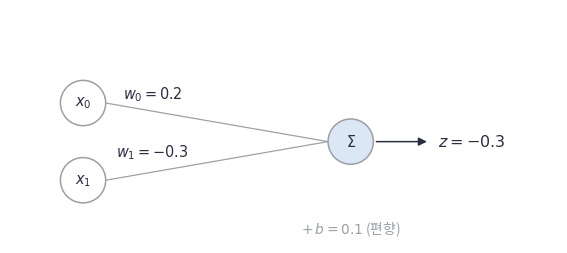

In [3]:
plot_neuron_diagram(["x_0", "x_1"], ["w_0=0.2", "w_1=-0.3"], "b=0.1", "z=-0.3")

🔍 **확인** · 위 도식이 이 절의 계산입니다. 입력 하나가 원 하나, 가중치 하나가 선 하나입니다.
가운데 $\Sigma$가 곱한 값들을 더하고 편향을 더해 $z$를 냅니다.

> **용어** · **뉴런(neuron)**: 입력 여러 개를 받아 "곱해서 더하고 편향을 더한" 숫자 하나를 내는 이 단위. 신경망은 뉴런을 여러 개 이어 붙인 것입니다.

In [4]:
def scalar_neuron(x0, x1, w0, w1, bias):
    """입력 두 개짜리 뉴런: z = x0·w0 + x1·w1 + b.
    입력·가중치·편향은 모두 숫자 하나(스칼라), 출력 z도 숫자 하나입니다."""
    return x0 * w0 + x1 * w1 + bias

In [5]:
z_hand = scalar_neuron(1.0, 2.0, 0.2, -0.3, 0.1)      # 붉기 1.0, 무게 2.0에 가중치 0.2, −0.3, 편향 0.1
np.testing.assert_allclose(z_hand, -0.3, atol=1e-15)  # 검산: 손계산 1·0.2 + 2·(−0.3) + 0.1 = −0.3
print("손계산 -0.3 · 코드", z_hand)

손계산 -0.3 · 코드 -0.29999999999999993


📎 **참고** · **검산이 무엇인가:** 수식을 코드로 옮긴 뒤에는 손으로 계산한 정답과 코드의 결과를 비교합니다. 이것을 검산이라고 부르겠습니다.
위 셀의 `assert_allclose`가 그 비교입니다. 컴퓨터는 소수를 유한한 자릿수로 저장하기 때문에 −0.3이 −0.29999…로 나올 수 있어,
아주 작은 차이는 허용하고 그보다 큰 차이는 오류를 내어 실행을 멈춥니다. 이 노트북의 검산 셀은 모두 이런 식입니다. 지나가도 됩니다.

통과한 검산은 아무것도 출력하지 않습니다. 그래서 검산 셀은 마지막에 `print`로 값을 보여 주고,
검산 줄 끝에는 `# 검산: 무엇 = 무엇` 주석으로 확인하는 내용을 적어 두었습니다.
조건이 틀렸을 때 보여 줄 문장은 `assert 조건, "문장"`처럼 뒤에 붙입니다.

## 🔑 2. 반복되는 항을 벡터와 합으로 씁니다

**이 절에서 가져갈 것:** 입력이 2개든 784개든, 가중치를 곱해 모두 더하는 계산은 코드 한 줄 `x @ w`로 씁니다.

입력이 두 개가 아니라 784개라면 $x_0w_0+x_1w_1+\cdots$를 다 적을 수 없습니다. 입력 개수를 $D$라고 쓰고 합 기호로 줄입니다.

$$z=\sum_{d=0}^{D-1}x_dw_d+b.$$

> **용어**
>
> - $\sum$ **(합 기호)**: 아래 인덱스를 0부터 $D-1$까지 바꾸어 가며 항을 **전부 더하라**는 뜻. 반복문 `for d in range(D)` 안에서 `total += x[d]*w[d]`와 같습니다.
> - **벡터(vector)**: 숫자를 순서대로 모은 1차원 배열. $x$와 $w$가 각각 벡터입니다.
> - **shape**: 배열의 각 축 길이. `(D,)`는 길이 $D$인 축 하나라는 뜻이고, 쉼표는 원소 하나짜리 Python 튜플 표기입니다.
> - **내적(dot product)**: 두 벡터의 같은 위치끼리 곱한 뒤 모두 더한 숫자 하나. 코드에서는 `x @ w`.

### 🔍 같은 내적을 이미지에서 보면

입력이 784개면 $z=\sum_{d=0}^{783}x_dw_d$입니다. $x$는 이미지의 화소 784개, $w$는 화소마다 하나씩 붙은 가중치 784개입니다.
$w$도 784개이므로 **28×28로 접으면 이미지처럼 볼 수 있습니다.**

$w$를 정하는 학습은 01번에서 하고, 여기서는 학습 없이 만들 수 있는 가장 단순한 가중치를 씁니다.
"7의 평균 이미지에서 전체 평균 이미지를 뺀 것"입니다. 7이 자주 지나가는 자리는 양수, 다른 숫자가 지나가는 자리는 음수가 됩니다.

$$w^{(7)}=\frac{1}{N_7}\sum_{n:\,y_n=7}x_n-\frac{1}{N}\sum_{n}x_n .$$

> **용어** · **템플릿(template)**: "이 숫자는 대체로 이렇게 생겼다"를 담은 가중치 이미지. 내적 $x\cdot w$는 이미지가 템플릿과 얼마나 겹치는지 재는 점수가 됩니다.

In [6]:
# 쓰는 것: X_train, y_train (60,000장과 정답) · X_examples (예시 10장) · 모두 위 📎 데이터 셀에서 만들었습니다
mean_all = X_train.mean(axis=0)                                # (784,): 60,000장을 화소마다 평균한 "전체 평균 이미지". 수식의 두 번째 항
template_7 = X_train[y_train == 7].mean(axis=0) - mean_all     # (784,): 정답이 7인 행만 골라(y_train == 7) 평균한 뒤 전체 평균을 뺀 템플릿
x_seven, x_two = X_examples[7], X_examples[2]                  # (784,) 둘: 예시 7과 예시 2를 한 줄로 편 것
products = [x_seven * template_7, x_two * template_7]          # 위치별 곱 x*w, (784,) 두 개. 그림의 가운데 판
scores = [x_seven @ template_7, x_two @ template_7]            # 곱을 모두 더한 내적 = 점수. 숫자 하나씩 두 개
assert scores[0] > 0, "7은 7 템플릿과 겹쳐 점수가 양수여야 합니다"
assert scores[1] < 0, "2는 7 템플릿과 어긋나 점수가 음수여야 합니다"
print("7의 점수", round(scores[0], 3), "· 2의 점수", round(scores[1], 3))

7의 점수 6.347 · 2의 점수 -2.701


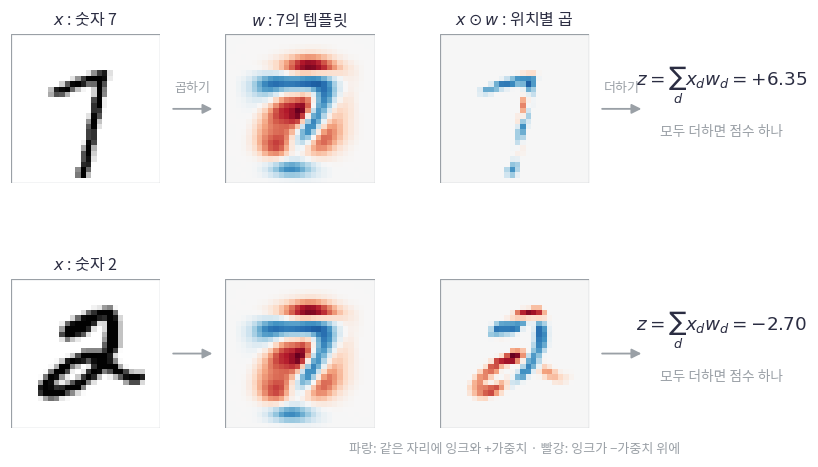

In [7]:
plot_dot_as_overlap([example_images[7], example_images[2]], template_7.reshape(28, 28),   # 그림용: 784짜리 벡터를 28×28로 접습니다
                    [p.reshape(28, 28) for p in products], scores, [7, 2])

🔍 **확인** · 곱 $x\odot w$는 잉크가 있는 자리에서만 값이 남습니다. 7의 잉크는 템플릿의 양수 자리를 지나 파랑이 많고,
2의 잉크는 음수 자리를 지나 빨강이 많습니다. `@`는 이 784개 값을 하나로 더해 **점수 하나**를 만듭니다.
이것이 내적을 "곱해서 더하는" 이유입니다. 두 배열이 같은 자리에서 얼마나 같은 방향인지 재는 것입니다.

In [8]:
def dot_loop(x, w):
    """내적을 반복문으로: Σ_d x[d]·w[d]. 2절의 합 기호를 그대로 옮긴 것입니다.
    x, w: (D,) 벡터 두 개 → 숫자 하나."""
    total = 0.0                          # 합을 모을 자리. 0에서 시작합니다
    for d in range(len(x)):              # d = 0, 1, …, D−1 (합 기호의 아래 인덱스)
        total += x[d] * w[d]             # 같은 위치끼리 곱해 더합니다
    return total


def vector_neuron(x, w, bias):
    """같은 계산을 배열 연산 한 줄로: z = x·w + b. `@` 하나가 위 반복문 전체입니다.
    x, w: (D,), bias: 숫자 → z: 숫자 하나."""
    return x @ w + bias

In [9]:
# 쓰는 것: z_hand (1절의 손계산 −0.3) · x_seven, template_7, scores (앞 그림 셀의 7 이미지·템플릿·점수)
x = np.array([1.0, 2.0])                 # (2,): 1절의 입력 두 개를 벡터 하나로
w = np.array([0.2, -0.3])                # (2,): 가중치 두 개
bias = 0.1
contributions = x * w                    # (2,): 위치별 곱. 아직 더하지 않은 상태
z_loop = dot_loop(x, w) + bias           # 반복문으로 더한 값
z_vector = vector_neuron(x, w, bias)     # @ 로 더한 값
np.testing.assert_allclose([z_loop, z_vector], [z_hand, z_hand])      # 검산: 두 방법 모두 1절 손계산 −0.3과 같음
print("x.shape =", x.shape, "w.shape =", w.shape)
print("x * w =", contributions, "(위치별 곱)")
print("x @ w =", x @ w, "(곱한 뒤 더한 스칼라)")
np.testing.assert_allclose(dot_loop(x_seven, template_7), scores[0])   # 검산: 784개짜리도 반복문 = @. 앞 그림의 7 점수와 같음

x.shape = (2,) w.shape = (2,)
x * w = [ 0.2 -0.6] (위치별 곱)
x @ w = -0.39999999999999997 (곱한 뒤 더한 스칼라)


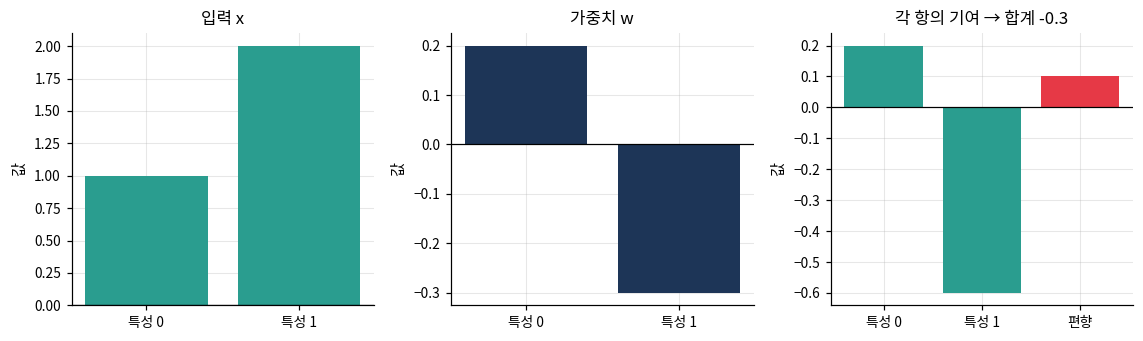

In [10]:
plot_weighted_sum(x, w, contributions, bias, z_vector)

🔍 **확인** · 첫 입력은 출력에 $+0.2$, 두 번째 입력은 $-0.6$, 편향은 $+0.1$만큼 기여합니다.
`*`는 위치별 곱을 그대로 남기고, `@`는 곱한 뒤 더해 숫자 하나로 줄입니다. 그림의 세 번째 판이 이 차이입니다.

✏️ **바꿔 보기:** `x[1]`만 3으로 바꾸면 출력은 얼마나 달라질까요?
두 번째 가중치 $-0.3$이 "이 입력이 1 커질 때 출력이 얼마나 변하는가"입니다.

In [11]:
x_changed = x.copy()                                     # 원래 x를 건드리지 않도록 복사본을 만듭니다
x_changed[1] = 3.0                                       # 두 번째 입력만 2 → 3
change = vector_neuron(x_changed, w, bias) - z_vector    # 출력의 변화량
np.testing.assert_allclose(change, -0.3)                 # 검산: 입력 x1이 1 커지면 출력은 w1 = −0.3만큼 변함
print("두 번째 입력을 1 늘렸을 때 출력 변화:", change)

두 번째 입력을 1 늘렸을 때 출력 변화: -0.30000000000000004


## 🔑 3. 샘플 여러 개를 행으로 모읍니다

**이 절에서 가져갈 것:** 샘플 $N$개를 행으로 쌓아 `(N, D)` 행렬 $X$를 만들면, `X @ w` 한 번으로 샘플 $N$개의 출력이 한꺼번에 나옵니다.

과일 하나가 아니라 과일 $N$개의 점수를 한꺼번에 내고 싶습니다. 같은 가중치를 모든 과일에 씁니다.

> **용어**
>
> - **샘플(sample)**: 데이터 한 개. 과일 하나, 이미지 한 장.
> - **특성(feature)**: 샘플 하나를 이루는 숫자 하나. 붉기, 무게, 또는 화소 하나. 샘플마다 특성이 $D$개.
> - **행렬(matrix)**: 숫자를 행과 열로 배열한 2차원 배열. 여기서는 **행은 샘플, 열은 특성**이라는 규약을 씁니다.

$$z_n=\sum_{d=0}^{D-1}X_{nd}w_d+b,\qquad n=0,\ldots,N-1.$$

남는 인덱스는 샘플 번호 $n$이고, 합으로 사라지는 인덱스는 특성 번호 $d$입니다.
코드로 옮기기 전에 "어떤 축을 더하고 어떤 축을 남기는가?"를 묻는 습관을 들입니다.

| 기호 | 모양 | 의미 |
|---|---|---|
| $X$ | `(N, D)` | $N$개 샘플의 $D$개 특성 |
| $w$ | `(D,)` | 모든 샘플에 공통으로 쓸 가중치 |
| $b$ | 스칼라 | 모든 샘플에 더할 편향 |
| $z$ | `(N,)` | 샘플마다 하나의 출력 |

### 🔍 이미지 10장을 행으로 쌓으면

예시 10장을 `(10, 784)`로 쌓은 것이 $X$입니다. `X @ template_7`은 반복문 없이 점수 10개를 한 번에 냅니다.
행 하나하나가 앞 절의 $x$이고, 결과의 $n$번째 값은 $n$번째 이미지의 점수입니다.

In [12]:
# 쓰는 것: X_examples (📎 데이터 셀, (10, 784)) · template_7 (2절)
scores_examples = X_examples @ template_7                # (10,): 행마다 내적 → 이미지마다 7 템플릿 점수 하나
assert np.argmax(scores_examples) == 7, "10장 중 7의 점수가 가장 커야 합니다"   # argmax: 가장 큰 값이 몇 번째인지
print("점수", scores_examples.round(2))

점수 [-7.15 -5.8  -2.7  -8.53 -2.7  -3.3  -8.12  6.35 -4.14  1.99]


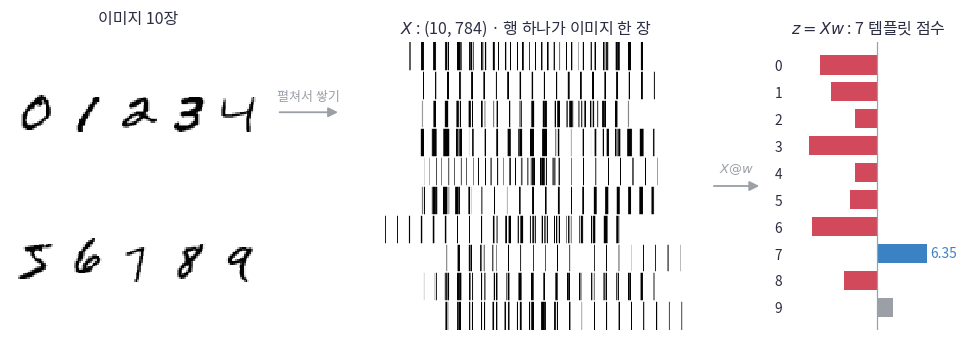

In [13]:
plot_batch_rows(example_images, X_examples, scores_examples, example_labels)

🔍 **확인** · 가운데 그림에서 행 하나는 이미지 한 장을 한 줄로 편 것입니다. 획이 지나가는 자리에만 검은 칸이 있습니다.
같은 $w$를 열 개 행 모두에 곱했으므로 파라미터는 그대로 784개이고, 점수만 행 수만큼 나옵니다.
7의 점수가 가장 크고 다른 숫자는 대부분 음수입니다.

In [14]:
def batch_neuron_loop(X, w, bias):
    """샘플마다 내적을 반복문으로: z[n] = X[n]·w + b.
    X: (N, D) 행 하나가 샘플 하나, w: (D,), bias: 숫자 → z: (N,)."""
    # 쓰는 것: dot_loop (2절)
    output = np.empty(len(X))                       # (N,): 결과를 담을 빈 배열. np.empty는 값을 채우기 전의 자리만 만듭니다
    for n in range(len(X)):                         # n번째 행 = n번째 샘플
        output[n] = dot_loop(X[n], w) + bias        # 2절의 내적에 편향을 더합니다
    return output

In [15]:
# 쓰는 것: w, bias (2절) · X_examples, template_7, scores_examples (앞 그림 셀)
X = np.array([[1.0, 2.0], [3.0, -1.0], [-2.0, 1.0]])      # (3, 2): 과일 3개 × 특성 2개(붉기, 무게). 첫 행이 2절의 x
z_batch_loop = batch_neuron_loop(X, w, bias)               # (3,): 반복문
z_batch = X @ w + bias                                     # (3,): 행렬 @ 벡터 한 줄. 행마다 내적, b는 모든 행에 더해짐
expected = np.array([-0.3, 1.0, -0.6])                     # 손계산: 행마다 x0·0.2 + x1·(−0.3) + 0.1
np.testing.assert_allclose(z_batch_loop, expected)         # 검산: 반복문 = 손계산
np.testing.assert_allclose(z_batch, expected)              # 검산: X @ w + b = 손계산
print("X.shape", X.shape, "→ z.shape", z_batch.shape)
print("출력", z_batch)
np.testing.assert_allclose(batch_neuron_loop(X_examples, template_7, 0.0), scores_examples)   # 검산: 앞 그림의 점수 10개도 반복문과 같음

X.shape (3, 2) → z.shape (3,)
출력 [-0.3  1.  -0.6]


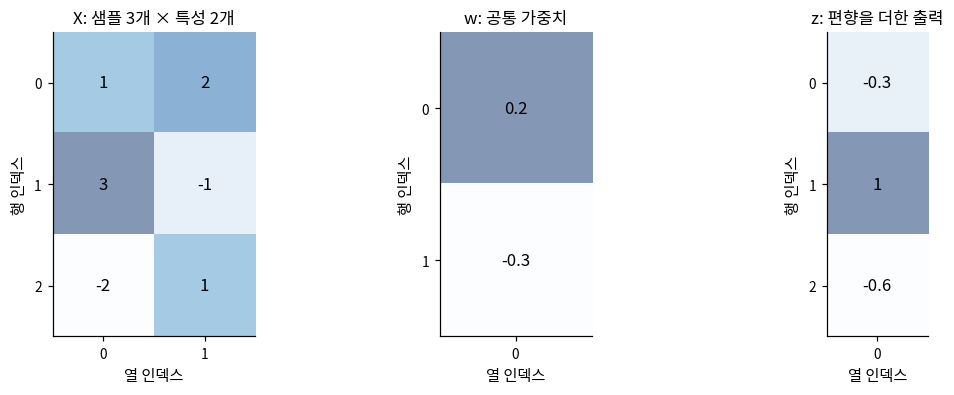

In [16]:
plot_product(X, w, z_batch,
             ["X: 샘플 3개 × 특성 2개", "w: 공통 가중치", "z: 편향을 더한 출력"])

🔍 **확인** · 행마다 같은 $w$와 $b$를 사용했습니다. 행을 늘려도 파라미터 개수는 그대로입니다.
`X @ w`는 샘플별 내적을 한 번에 계산합니다.

> **용어** · **벡터화(vectorization)**: 반복문으로 하나씩 하던 계산을 배열 연산 한 줄로 바꾸는 것. 결과는 같고 훨씬 빠릅니다.

📎 출력 하나를 일부러 열벡터 `(N, 1)`로 유지하려면 가중치도 `(D, 1)`로 두면 됩니다. 아래 셀은 그 확인입니다.

In [17]:
# 쓰는 것: w, bias (2절) · X, z_batch (앞 검산 셀)
w_column = w[:, None]                    # (2, 1): None 자리에 길이 1인 새 축이 생겨 열벡터가 됩니다
z_column = X @ w_column + bias           # (3, 2) @ (2, 1) → (3, 1)
assert w_column.shape == (2, 1) and z_column.shape == (3, 1), "w를 (D, 1)로 세우면 출력은 (N, 1)입니다"
np.testing.assert_allclose(z_column[:, 0], z_batch)   # 검산: 열 하나를 꺼내면 위의 (N,) 출력과 같음
print("열벡터로 유지한 출력:\n", z_column)

열벡터로 유지한 출력:
 [[-0.3]
 [ 1. ]
 [-0.6]]


## 🔑 4. 출력도 여러 개로 늘립니다

**이 절에서 가져갈 것:** 출력이 $K$개면 가중치는 `(D, K)` 행렬 $W$이고, 열 하나가 출력 하나의 가중치입니다. `(N, D) @ (D, K) → (N, K)`.

과일의 "익음 점수" 하나가 아니라 "익음·단맛·크기" 점수 $K$개를 내고 싶습니다. 점수마다 자기 가중치 벡터가 필요하니 벡터 $K$개를 열로 나란히 붙입니다.

$$Z_{nk}=\sum_{d=0}^{D-1}X_{nd}W_{dk}+b_k,$$

$$\underbrace{Z}_{(N,K)}=\underbrace{X}_{(N,D)}\underbrace{W}_{(D,K)}+\underbrace{b}_{(K,)}.$$

> **용어**
>
> - **행렬곱** $XW$: 왼쪽의 각 행과 오른쪽의 각 열을 내적해 채운 표. 곱하는 두 행렬의 안쪽 차원 $D$가 같아야 하고, 바깥쪽 `(N, K)`가 남습니다.
> - **아핀 변환(affine transformation)**: 행렬곱에 편향을 더한 계산. 신경망에서는 흔히 **선형층(linear layer)**이라고 부릅니다.

### 🔍 열 10개를 나란히 두면 출력 10개

숫자마다 템플릿을 하나씩 만들어 열로 나란히 붙이면 $W$는 `(784, 10)`입니다.
$Z=XW$는 `(10, 10)`이고, $Z_{nk}$는 **$n$번째 이미지가 $k$번째 템플릿과 겹치는 점수**입니다.
행에서 가장 큰 점수의 열을 고르면 가장 닮은 숫자를 고른 셈입니다.

> **코드**
>
> - `[식 for k in range(10)]`(리스트 컴프리헨션): k를 0부터 9까지 바꾸며 식을 계산한 결과 10개를 목록으로 모읍니다. 반복문 안에서 `append`하는 것과 같습니다.
> - `np.stack(목록, axis=1)`: 같은 모양의 배열 여러 개를 새 축으로 쌓습니다. `axis=1`이면 `(784,)` 벡터 10개가 열이 되어 `(784, 10)`이 됩니다.

In [18]:
# 쓰는 것: X_train, y_train, X_examples, example_labels (📎 데이터 셀) · mean_all, template_7 (2절)
W_templates = np.stack([X_train[y_train == k].mean(axis=0) - mean_all    # 숫자 k의 템플릿 (784,)을 k = 0…9에 대해 만들고
                        for k in range(10)], axis=1)                     # 열로 나란히 쌓아 (784, 10)
assert W_templates.shape == (784, 10), "템플릿 10장을 열로 쌓으면 (D, K) = (784, 10)입니다"
np.testing.assert_allclose(W_templates[:, 7], template_7)      # 검산: 7번 열은 2절의 template_7과 같음
Z_examples = X_examples @ W_templates                          # (10, 10): 행은 이미지, 열은 템플릿. Z[n, k] = n번째 이미지의 숫자 k 점수
predicted = np.argmax(Z_examples, axis=1)                      # (10,): 행마다 가장 큰 점수의 열 번호 = 가장 닮은 숫자
correct = (predicted == example_labels).sum()                  # 맞힌 장수. True를 1로 세어 더합니다
print("행별로 가장 큰 열:", predicted, f"· 10장 중 {correct}장이 정답과 같음")

행별로 가장 큰 열: [0 8 2 8 4 3 6 7 8 9] · 10장 중 7장이 정답과 같음


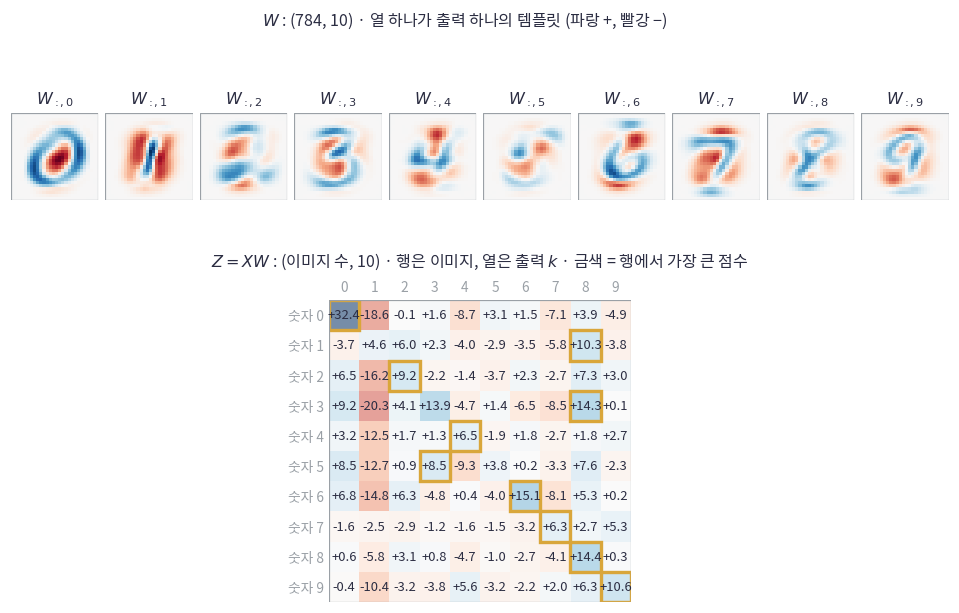

In [19]:
plot_templates(W_templates.reshape(28, 28, 10), Z_examples, example_labels)   # 그림용: 열 10개를 각각 28×28 이미지로

🔍 **확인** · 위 줄이 $W$의 열 10개입니다. 열 하나가 출력 하나에 쓰이는 가중치라는 말이 그림에서는 "열 하나가 템플릿 한 장"입니다.
아래 점수표에서 금색 칸은 행마다 가장 큰 점수입니다. 평균으로 만든 템플릿만으로도 10장 중 여러 장이 맞지만 틀리는 행도 있습니다.
0번 열은 잉크가 많은 어떤 이미지에나 큰 점수를 주고, 1번 열은 가늘지 않은 이미지에 큰 음수를 줍니다.
이 점수표를 정답에 맞게 고치는 것이 01번부터의 학습입니다.

🔍 **확인** · $W$를 도식으로 보면 **원소 하나가 선 하나**입니다. $W_{dk}$는 입력 $d$에서 출력 $k$로 가는 선의 가중치입니다.
입력이 784개, 출력이 10개여도 구조는 같고 선의 수만 $784\times10$으로 늘어납니다.

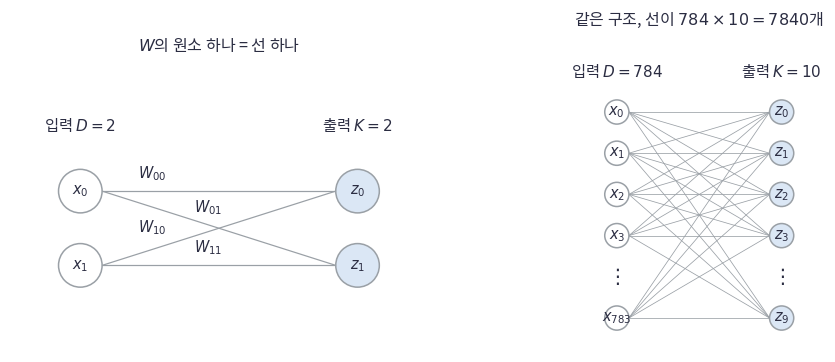

In [20]:
plot_layer_diagram(2, 2, [["W_{00}", "W_{01}"], ["W_{10}", "W_{11}"]], 784, 10)

In [21]:
def affine_loop(X, W, b):
    """아핀 계산을 삼중 반복문으로: Z[n, k] = Σ_d X[n, d]·W[d, k] + b[k].
    X: (N, D), W: (D, K), b: (K,) → Z: (N, K)."""
    N, D = X.shape
    K = W.shape[1]
    Z = np.empty((N, K))                    # 결과를 담을 빈 (N, K) 표
    for n in range(N):                      # 샘플마다
        for k in range(K):                  # 출력마다
            Z[n, k] = b[k]                  # 편향에서 시작해
            for d in range(D):              # 특성 축 d를 따라 곱해 더합니다. d가 합으로 사라지는 축
                Z[n, k] += X[n, d] * W[d, k]
    return Z


def affine(X, W, b):
    """같은 계산을 행렬곱 한 줄로: Z = X @ W + b.
    X: (N, D), W: (D, K), b: (K,) → Z: (N, K). 모양이 어긋나면 이유를 말하고 멈춥니다."""
    if X.ndim != 2 or W.ndim != 2 or b.shape != (W.shape[1],):
        raise ValueError("X는 (N,D), W는 (D,K), b는 (K,)로 둡니다.")
    if X.shape[1] != W.shape[0]:
        raise ValueError("X의 특성 수와 W의 입력 수가 같아야 합니다.")
    return X @ W + b                        # b (K,)는 브로드캐스팅으로 모든 행에 더해집니다 (5절)

In [22]:
# 쓰는 것: X (3절의 과일 3개) · X_examples, W_templates, Z_examples (앞 그림 셀)
W = np.array([[0.2, 1.0], [-0.3, 0.5]])            # (2, 2): 열 0은 익음 점수, 열 1은 단맛 점수의 가중치
b = np.array([0.1, -0.2])                          # (2,): 출력마다 편향 하나
Z_loop = affine_loop(X, W, b)                      # (3, 2): 삼중 반복문
Z = affine(X, W, b)                                # (3, 2): 행렬곱 한 줄
expected_Z = np.array([[-0.3, 1.8], [1.0, 2.3], [-0.6, -1.7]])   # 손계산: 열 0은 3절의 z 그대로, 열 1은 x0·1.0 + x1·0.5 − 0.2
np.testing.assert_allclose(Z_loop, expected_Z)     # 검산: 반복문 = 손계산
np.testing.assert_allclose(Z, expected_Z)          # 검산: X @ W + b = 손계산
print("X", X.shape, "@ W", W.shape, "+ b", b.shape, "→ Z", Z.shape)
print(Z)
np.testing.assert_allclose(affine(X_examples, W_templates, np.zeros(10)), Z_examples)   # 검산: 앞 그림의 점수표도 같은 함수로 나옴 (편향 0)

X (3, 2) @ W (2, 2) + b (2,) → Z (3, 2)
[[-0.3  1.8]
 [ 1.   2.3]
 [-0.6 -1.7]]


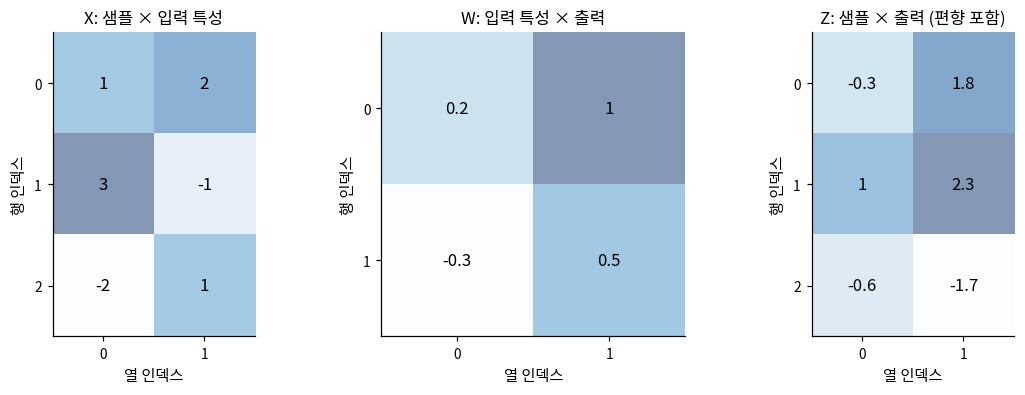

In [23]:
plot_product(X, W, Z,
             ["X: 샘플 × 입력 특성", "W: 입력 특성 × 출력", "Z: 샘플 × 출력 (편향 포함)"])

📎 **참고** · 반복문에서는 `n`, `k`, `d` 세 인덱스를 썼지만, 행렬곱은 그중 `d`를 합하는 규칙을 담고 있습니다.
뒤의 구조에서도 이 한 줄을 다시 만납니다. CNN(05)은 입력을 작은 이미지 조각으로 바꿔 같은 가중치를 위치마다 씁니다.
Attention(08)도 먼저 이런 행렬곱으로 입력을 다른 표현으로 바꿉니다.

## 🔑 5. 축과 브로드캐스팅을 확인합니다

**이 절에서 가져갈 것:** 모양이 다른 배열을 더할 때 NumPy가 작은 쪽을 반복해서 맞춥니다. `sum(axis=…)`에 적은 축은 사라지고 나머지 축이 남습니다.

`X @ W`는 `(N, K)`인데 `b`는 `(K,)`입니다. 모양이 다른데도 더할 수 있는 이유가 있습니다.

> **용어**
>
> - **축(axis)**: 배열의 차원 방향. 2차원 배열에서 `axis=0`은 행이 늘어나는 세로 방향, `axis=1`은 열이 늘어나는 가로 방향입니다.
> - **브로드캐스팅(broadcasting)**: 모양이 다른 배열을 연산할 때 NumPy가 뒤쪽 축부터 길이를 맞추고, 길이 1인 축은 반복해서 쓰는 것처럼 계산하는 규칙.

여기서는 편향을 샘플마다 공통으로 더합니다. 같은 값을 여러 샘플에 쓰는 관계가
다음 노트북의 편향 기울기에서 **샘플 축의 합**으로 돌아옵니다.

`sum(axis=0)`은 세로로 샘플들을 합쳐 `(K,)`를 남기고, `sum(axis=1)`은 가로로 출력들을 합쳐 `(N,)`을 남깁니다.
**`axis`에 적은 축이 사라지고 나머지가 남습니다.**

### 🔍 어느 축을 더하느냐에 따라 남는 것이 다릅니다

같은 $X$ `(10, 784)`에서 `axis=0`으로 평균하면 샘플 축이 사라지고 화소 784개가 남아 **이미지**가 됩니다.
`axis=1`로 더하면 화소 축이 사라지고 샘플 10개가 남아 **이미지마다 잉크 양** 하나가 됩니다.

In [24]:
# 쓰는 것: X_examples (📎 데이터 셀, (10, 784))
mean_image = X_examples.mean(axis=0)                 # (784,): axis=0(샘플 축)이 사라지고 화소마다 10장의 평균이 남음 → 이미지 한 장
ink_per_image = X_examples.sum(axis=1)               # (10,): axis=1(화소 축)이 사라지고 이미지마다 잉크 양 하나가 남음
assert mean_image.shape == (784,) and ink_per_image.shape == (10,), "axis=0은 (784,)을, axis=1은 (10,)을 남깁니다"
np.testing.assert_allclose(mean_image.sum() * 10, ink_per_image.sum())   # 검산: 어느 축으로 먼저 더해도 총합은 같음 (평균×10 = 합)
print("잉크 양", ink_per_image.round(0))

잉크 양 [122.  67. 116. 141.  76. 108. 112.  50. 106.  91.]


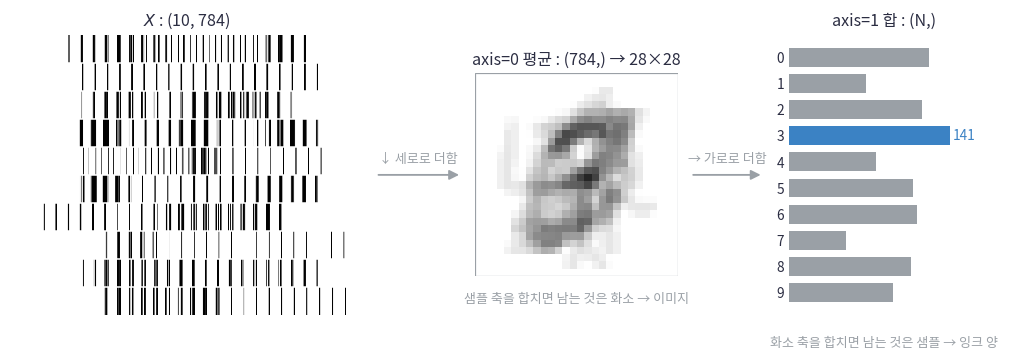

In [25]:
plot_axis_sums(X_examples, mean_image.reshape(28, 28), ink_per_image, example_labels)

🔍 **확인** · 앞 절의 편향 기울기에서 "샘플 축의 합"이 나오면 왼쪽처럼 세로로 더해 이미지 크기의 결과가 남는다고 읽으면 됩니다.
`keepdims=True`는 사라지는 축을 길이 1로 남겨 브로드캐스팅에 다시 쓰기 위한 것입니다.

In [26]:
# 쓰는 것: X, W, b, Z (4절의 과일 3개 × 출력 2개)
bias_rows = np.broadcast_to(b, Z.shape)                 # (3, 2): 브로드캐스팅이 실제로 만드는 표. b (2,)를 행마다 복사한 모양
np.testing.assert_allclose(X @ W + bias_rows, Z)        # 검산: 복사해서 더한 것 = 그냥 b를 더한 것
np.testing.assert_allclose(Z.sum(axis=0), [0.1, 2.4])   # 검산: 세로로 샘플을 합하면 출력마다 하나, (2,)
np.testing.assert_allclose(Z.sum(axis=1), [1.5, 3.3, -2.3])   # 검산: 가로로 출력을 합하면 샘플마다 하나, (3,)
print("샘플마다 적용되는 편향:\n", bias_rows)
print("axis=0: 샘플을 합함", Z.sum(axis=0))
print("axis=1: 출력을 합함", Z.sum(axis=1))
print("keepdims=True로 축을 남김", Z.sum(axis=0, keepdims=True).shape)   # (1, 2): 사라질 축을 길이 1로 남깁니다

샘플마다 적용되는 편향:
 [[ 0.1 -0.2]
 [ 0.1 -0.2]
 [ 0.1 -0.2]]
axis=0: 샘플을 합함 [0.1 2.4]
axis=1: 출력을 합함 [ 1.5  3.3 -2.3]
keepdims=True로 축을 남김 (1, 2)


### 🔑 모양이 맞아도 의미가 다를 수 있습니다

샘플 2개에 대해 각각 $+10$, $+20$을 더하려고 한다고 해 보겠습니다.
출력 개수도 2개이면 `(2,)`는 출력 축에 맞추어집니다.
샘플별 값을 더하려면 `(2, 1)`로 샘플 축을 명시합니다.

In [27]:
base = np.array([[1.0, 2.0], [3.0, 4.0]])      # (2, 2): 샘플 2개 × 출력 2개
per_sample = np.array([10.0, 20.0])            # (2,): 샘플마다 더하고 싶은 값
by_output = base + per_sample                  # (2,)는 뒤쪽 축(출력 축)에 맞춰져 열마다 더해짐: 의도와 다름
by_sample = base + per_sample[:, None]         # (2, 1)로 세우면 샘플 축에 맞춰져 행마다 더해짐: 의도대로
np.testing.assert_array_equal(by_output, [[11.0, 22.0], [13.0, 24.0]])   # 검산: 열마다 +10, +20
np.testing.assert_array_equal(by_sample, [[11.0, 12.0], [23.0, 24.0]])   # 검산: 행마다 +10, +20
assert not np.array_equal(by_output, by_sample), "같은 숫자 둘이라도 어느 축에 맞추느냐에 따라 결과가 다릅니다"
print("(2,)를 더했을 때:\n", by_output)
print("(2,1)을 더했을 때:\n", by_sample)

(2,)를 더했을 때:
 [[11. 22.]
 [13. 24.]]
(2,1)을 더했을 때:
 [[11. 12.]
 [23. 24.]]


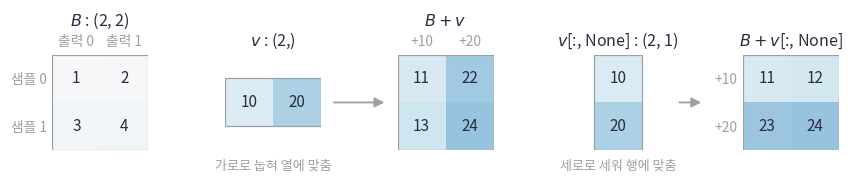

In [28]:
plot_broadcast_ways(base, per_sample, by_output, by_sample)

🔍 **확인** · 같은 숫자 두 개(10, 20)인데 눕히면 열마다, 세우면 행마다 더해집니다.
숫자의 크기가 우연히 같으면 실행 오류가 생기지 않아도 의도와 다른 축으로 계산할 수 있습니다.
따라서 shape 옆에 **샘플·특성·출력이라는 의미**도 적습니다.

## 🔑 6. reshape와 transpose는 다른 일을 합니다

**이 절에서 가져갈 것:** `reshape`는 원소 순서를 지키며 모양만 바꾸고, `transpose`는 축을 맞바꿉니다. 둘은 다른 배열을 만듭니다.

> **용어**
>
> - **reshape**: 원소를 읽는 순서는 그대로 두고 행·열 개수만 다시 잡는 것. 28×28 이미지를 784짜리 한 줄로 펴는 데 씁니다.
> - **transpose**(`.T`): 축을 교환하는 것. 2차원에서는 행과 열이 바뀝니다.

원소 수가 같다는 것만으로 같은 배열이 되지는 않습니다.
아래 세 배열에서 숫자 1의 위치를 먼저 예상해 보세요.

### 🔍 이미지에서 보면 차이가 분명합니다

`reshape(784)`는 28행을 순서대로 이어 붙인 것이라 `reshape(28, 28)`로 그대로 되돌아옵니다.
`.T`는 행과 열을 바꾸므로 그림이 대각선으로 뒤집힙니다. 원소 수가 같은 `reshape(14, 56)`은 오류 없이 실행되지만 그림이 아닙니다.

In [29]:
# 쓰는 것: example_images (📎 데이터 셀, (10, 28, 28))
seven = example_images[7]                                       # (28, 28): 예시 7 한 장
flat = seven.reshape(784)                                       # (784,): 28행을 순서대로 이어 붙여 한 줄로
np.testing.assert_array_equal(flat.reshape(28, 28), seven)      # 검산: 같은 순서로 다시 접으면 원래 이미지
assert not np.array_equal(seven.T, seven) and seven.T.shape == (28, 28), "전치는 모양은 같아도 다른 배열입니다"
wrong = seven.reshape(14, 56)                                   # 원소 수 784가 같아서 오류 없이 실행되지만 그림이 아닙니다
assert wrong.size == seven.size, "reshape는 원소 수를 바꾸지 않습니다"
print("검산 통과: reshape(784) → reshape(28, 28)은 원래대로, .T는 다른 배열, (14, 56)도 원소 수는", wrong.size)

검산 통과: reshape(784) → reshape(28, 28)은 원래대로, .T는 다른 배열, (14, 56)도 원소 수는 784


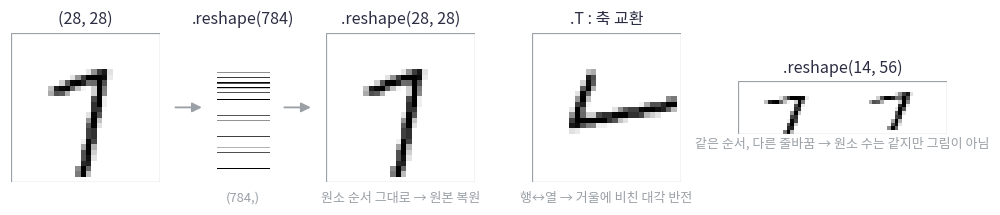

In [30]:
plot_reshape_vs_transpose(seven, flat, flat.reshape(28, 28), seven.T, wrong)

In [31]:
original = np.arange(6).reshape(2, 3)            # (2, 3): 0부터 5까지를 2행 3열로. 숫자 1의 위치를 눈여겨보세요
transposed = original.T                          # (3, 2): 행과 열을 맞바꿈. 1은 (0, 1)에서 (1, 0)으로
reshaped = original.reshape(3, 2)                # (3, 2): 읽는 순서 0,1,2,3,4,5 그대로 3행 2열로 다시 채움. 1은 (0, 1)에 그대로
np.testing.assert_array_equal(transposed, [[0, 3], [1, 4], [2, 5]])   # 검산: transpose
np.testing.assert_array_equal(reshaped, [[0, 1], [2, 3], [4, 5]])     # 검산: reshape
assert not np.array_equal(transposed, reshaped), "모양이 같은 (3, 2)여도 transpose와 reshape는 다른 배열입니다"
print("원본:\n", original)
print("transpose:\n", transposed)
print("reshape:\n", reshaped)

원본:
 [[0 1 2]
 [3 4 5]]
transpose:
 [[0 3]
 [1 4]
 [2 5]]
reshape:
 [[0 1]
 [2 3]
 [4 5]]


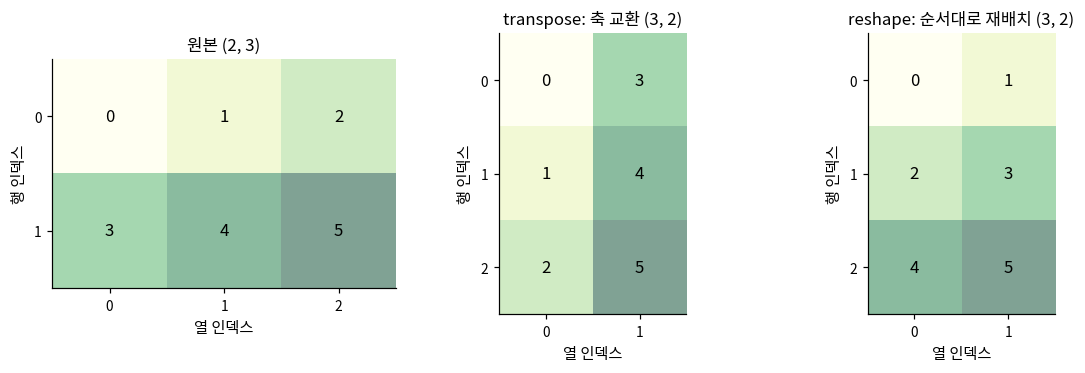

In [32]:
plot_layout(original, transposed, reshaped)

🔍 **확인** · 행과 열의 의미를 교환하려면 transpose를 씁니다.
기울기 식에 $X^\top$가 나타나면 `X.T`로 옮기는 이유입니다.
reshape가 필요한 경우에는 어느 축의 원소들이 어떤 순서로 묶이는지 따로 확인합니다.

## 📎 7. 같은 계산을 그림으로 봅니다

두 입력에 대한 출력 $z=0.2x_0-0.3x_1+0.1$은 평면입니다.
입력 좌표를 움직이면 가중치가 정한 기울기로 출력이 변합니다. 이 절은 1절의 계산을 다른 각도에서 한 번 더 보는 것이라 건너뛰어도 뒤에 지장이 없습니다.

격자 좌표와 예측값은 아래에서 직접 계산합니다. 좌표를 평면 그림의 입력으로 바꾸는 과정도 배열 연산입니다.

| 연산 | 의미 | 이 예제의 shape |
|---|---|---|
| `np.linspace(-3, 3, 35)` | -3부터 3까지 같은 간격의 숫자 35개 만들기 | `(35,)` |
| `np.meshgrid(x좌표, y좌표)` | 가능한 모든 좌표 쌍을 두 격자로 펼치기 | `xx`, `yy` 각각 `(35, 35)` |
| `xx.ravel()`, `yy.ravel()` | 각 격자를 같은 순서로 한 줄에 펴기 | 각각 `(1225,)` |
| `np.column_stack([...])` | 두 좌표 목록을 열로 나란히 붙이기 | `points`: `(1225, 2)` |
| `points @ w + bias` | 좌표 한 쌍을 샘플 한 개로 보고 출력 계산하기 | `(1225,)` |
| `.reshape(xx.shape)` | 출력 1225개를 원래 격자 위치에 놓기 | `zz`: `(35, 35)` |

`xx[i, j]`와 `yy[i, j]`가 한 점의 두 좌표입니다. 격자의 행은 $x_1$, 열은 $x_0$의 위치를 나타냅니다.

In [33]:
# 쓰는 것: w, bias (2절의 가중치와 편향)
xx, yy = np.meshgrid(np.linspace(-3, 3, 35), np.linspace(-3, 3, 35))   # (35, 35) 둘: 격자의 모든 x0, x1 좌표 (위 표 참고)
points = np.column_stack([xx.ravel(), yy.ravel()])                     # (1225, 2): 좌표 쌍 하나가 샘플 하나인 X 모양
zz = (points @ w + bias).reshape(xx.shape)                             # (1225,) 출력을 다시 (35, 35) 격자에 놓음
np.testing.assert_allclose(zz, 0.2 * xx - 0.3 * yy + 0.1)              # 검산: 격자 위의 출력 = 0.2·x0 − 0.3·x1 + 0.1
print("격자", xx.shape, "→ 샘플 행렬", points.shape, "→ 출력 격자", zz.shape)

격자 (35, 35) → 샘플 행렬 (1225, 2) → 출력 격자 (35, 35)


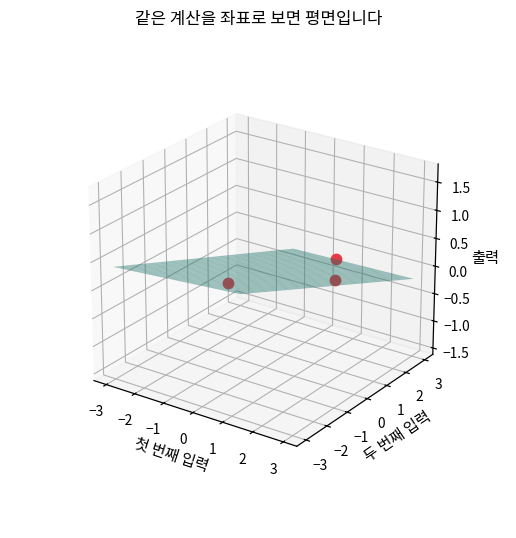

In [34]:
plot_affine_plane(xx, yy, zz, X, z_batch)   # 3절의 과일 3개도 평면 위의 점으로 함께 그립니다

🔍 **확인** · 평면의 방향은 가중치가, 전체 높이는 편향이 결정합니다.
다음 노트북에서는 관측된 정답에 맞추어 이 방향과 높이를 갱신합니다.

## ✏️ 8. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 출력이 K개인 아핀 계산 (4절)

입력 `(N, D)`, 가중치 `(D, K)`, 편향 `(K,)`에서 출력 `(N, K)`를 만드는 한 줄을 채우세요.

In [35]:
def exercise_affine(X, W, b):
    """연습 A: 아핀 계산. X: (N, D), W: (D, K), b: (K,) → Z: (N, K)."""
    if X.shape[1] != W.shape[0] or b.shape != (W.shape[1],):
        raise ValueError("X는 (N,D), W는 (D,K), b는 (K,)로 둡니다.")
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: X와 W의 행렬곱에 b를 더한 Z (모양 (N, K))
    ### 힌트: 4절의 affine 함수 본문 한 줄입니다. 편향은 브로드캐스팅으로 모든 행에 더해집니다.
    raise NotImplementedError
    return Z

In [36]:
def check_three_outputs(candidate):
    """손계산 예제 하나로 후보 함수를 검사합니다. 통과하면 메시지를 출력합니다."""
    example_X = np.array([[1., 2.], [-1., 3.]])                 # (2, 2)
    example_W = np.array([[1., 0., -2.], [0.5, 2., 1.]])        # (2, 3)
    example_b = np.array([0., 1., -1.])                         # (3,)
    actual = candidate(example_X, example_W, example_b)
    assert actual.shape == (2, 3), f"출력 모양은 (N, K) = (2, 3)이어야 하는데 {actual.shape}입니다"
    np.testing.assert_allclose(actual, [[2., 5., -1.], [0.5, 7., 4.]])   # 검산: 손계산. 행 0은 [1·1+2·0.5, 0+2·2, −2+2·1] + b
    print("출력 3개: 손계산과 일치합니다.")

run_check(check_three_outputs, exercise_affine, hint="Z = X @ W + b")

☐ exercise_affine: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: Z = X @ W + b


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
Z = X @ W + b
```

</details>

### ✏️ 연습 B · 샘플별 값 더하기 (5절)

`base`는 `(N, K)`, `per_sample`은 `(N,)`입니다. 각 **행**에 그 샘플의 값을 더하려면 `(N,)`을 `(N, 1)`로 세워야 합니다.

In [37]:
def exercise_add_per_sample(base, per_sample):
    """연습 B: 행마다 다른 값 더하기. base: (N, K), per_sample: (N,) → (N, K)."""
    assert base.shape[0] == per_sample.shape[0], "base와 per_sample의 샘플 수 N이 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: base의 n번째 행마다 per_sample[n]을 더한 배열 (모양 base와 같음)
    ### 힌트: per_sample[:, None]은 (N, 1)입니다. 5절의 by_sample 계산입니다.
    raise NotImplementedError
    return result

In [38]:
def check_add_per_sample(candidate):
    """5절의 손계산 예제와 (3, 4) 배열 하나로 검사합니다. 통과하면 메시지를 출력합니다."""
    base = np.array([[1., 2.], [3., 4.]])
    actual = candidate(base, np.array([10., 20.]))
    np.testing.assert_array_equal(actual, [[11., 12.], [23., 24.]])   # 검산: 행마다 +10, +20 (5절의 by_sample)
    three = candidate(np.zeros((3, 4)), np.array([1., 2., 3.]))
    np.testing.assert_array_equal(three[:, 0], [1., 2., 3.])          # 검산: 첫 열을 보면 행마다 1, 2, 3
    print("샘플별 더하기: 손계산과 일치합니다.")

run_check(check_add_per_sample, exercise_add_per_sample, hint="result = base + per_sample[:, None]")

☐ exercise_add_per_sample: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: result = base + per_sample[:, None]


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
result = base + per_sample[:, None]
```

</details>

### ✏️ 연습 C · 이미지를 펼치기 (6절)

`(N, 28, 28)` 이미지 묶음을 `(N, 784)`로 펼치는 한 줄을 채우세요. 원소 순서는 그대로여야 합니다.

In [39]:
def exercise_flatten(images):
    """연습 C: 이미지 묶음 펼치기. images: (N, 28, 28) → flat: (N, 784)."""
    assert images.ndim == 3, "images는 (N, 28, 28) 3차원 배열이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 이미지 N장을 행 N개짜리 (N, 784) 행렬로 펼치기
    ### 힌트: reshape(N, -1)에서 -1은 "나머지를 알아서"입니다. transpose가 아닙니다.
    raise NotImplementedError
    return flat

In [40]:
def check_flatten(candidate):
    """📎 데이터 셀의 예시 10장으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: example_images, X_examples (📎 데이터 셀)
    flat = candidate(example_images)
    assert flat.shape == (10, 784), f"모양은 (10, 784)여야 하는데 {flat.shape}입니다"
    np.testing.assert_array_equal(flat, X_examples)                          # 검산: 본문에서 펼친 X_examples와 같음
    np.testing.assert_array_equal(flat[7].reshape(28, 28), example_images[7])   # 검산: 다시 접으면 원래 이미지 (순서가 지켜짐)
    print("펼치기: 00번 본문의 X_examples와 일치합니다.")

run_check(check_flatten, exercise_flatten, hint="flat = images.reshape(len(images), -1)")

☐ exercise_flatten: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: flat = images.reshape(len(images), -1)


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
flat = images.reshape(len(images), -1)
```

</details>

### ✏️ 준비도 질문 · 다음 노트북으로 갈 준비

예제 셀을 가리고 다음을 설명하거나 작성해 보세요. 🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

1. 입력 `(5, 4)`, 가중치 `(4, 3)`, 편향 `(3,)`의 출력 모양을 정할 수 있나요?
2. $Z_{nk}=\sum_d X_{nd}W_{dk}+b_k$에서 합하는 축과 남는 축을 말할 수 있나요?
3. 샘플별 값을 더할 때와 출력별 값을 더할 때 배열 모양을 다르게 정할 수 있나요?
4. 4절의 반복문과 벡터화 함수를 직접 다시 작성할 수 있나요?
5. 내적을 "이미지와 템플릿의 겹침"으로, $W$의 열을 "템플릿 한 장"으로 설명할 수 있나요?

막힌 항목에 해당하는 절을 다시 보고, 숫자나 차원을 바꿔 한 번 더 검산합니다.

**다음:** [01 · 미분으로 학습시키기](01_gradients_and_learning.ipynb).
지금 계산한 출력의 오차를 이용해 $W$와 $b$를 어떻게 바꿀지 직접 유도합니다.